# DUMPLINGs Series Analysis Control Panel

A lightweight local notebook for experiment-series analysis.

The main view here is an aggregate epoch-wise curve: median trajectory plus a semi-transparent band. By default that band is IQR (`q25-q75`), with `std` and uncertainty-style alternatives available as other modes.

In [2]:
import matplotlib.pyplot as plt

from scripts.series_analysis import (
    filter_registry,
    load_registry,
    load_series_histories,

    plot_metric_summary_scatter,
    plot_series_panel,
    summarize_series,

    load_series_readout_diagnostics,
    summarize_a3_mixture_diagnostics,

    plot_a3_alpha_beta_scatter,
    plot_a3_local_ratio_vs_metric,
    plot_a3_mixture_parameters
)


In [3]:
RUNS_DIR = "runs"

In [4]:
RUN_PREFIXES = []
EXPERIMENT_NAMES = []
# ===========================================================================
registry = load_registry(f"{RUNS_DIR}/experiment_registry.csv")
registry_view = filter_registry(
    registry,
    experiment_names=EXPERIMENT_NAMES or None,
    prefixes=RUN_PREFIXES or None,
)
summary = summarize_series(registry_view)

print(f"registry rows: {len(registry)}")
print(f"filtered rows: {len(registry_view)}")
display(summary)

FOCUS_SERIES = "DUMPLING_A1_full"
history_df = load_series_histories(registry_view, FOCUS_SERIES, runs_dir=RUNS_DIR)
print(f"history rows: {len(history_df)}")
display(history_df.head())


registry rows: 115
filtered rows: 115


,experiment_name,observed,success,duration_mean,duration_std,pearson_mean,pearson_std,rmse_mean,rmse_std,ci_mean,ci_std
0,DUMPLING_A15_esm_DimeNet,2,2,0.00,0.000000,0.775268,0.007608,1.376395,0.022552,0.785031,0.005728
1,DUMPLING_A15_esm_DimeNet_ligand_context_test,1,1,0.00,0.000000,0.775293,0.000000,1.377129,0.000000,0.786201,0.000000
2,DUMPLING_A1_DimeNet,2,1,0.00,0.000000,0.680923,0.000000,0.814077,0.000000,0.736852,0.000000
3,DUMPLING_A1_dimenet_esm,10,10,3633.73,765.916618,0.767670,0.010391,1.404230,0.027129,0.781738,0.005354
4,DUMPLING_A1_dimenet_only,10,10,5255.27,980.875517,0.715578,0.020758,1.544201,0.062712,0.757444,0.008976
5,DUMPLING_A1_esm_only,10,10,771.38,234.787835,0.511018,0.009442,1.876848,0.012761,0.668833,0.003494
6,DUMPLING_A1_full,10,10,3650.67,774.427839,0.769934,0.009659,1.394071,0.025832,0.784142,0.005858
7,DUMPLING_A1b_DimeNet_ESM_only_ESM,1,1,0.00,0.000000,0.510115,0.000000,0.951415,0.000000,0.668560,0.000000
8,DUMPLING_A1b_DimeNet_Initial_milestone_bs2,1,1,0.00,0.000000,0.686673,0.000000,0.809141,0.000000,0.749719,0.000000
9,DUMPLING_A2_first_run,3,3,0.00,0.000000,0.761431,0.028842,1.456668,0.065078,0.779691,0.014575


history rows: 5640


,experiment_signature,splitter_seed,batch_run_index,epoch,train_rmse,val_rmse,train_loss,val_loss,train_pearson,val_pearson
0,DUMPLING_A1_full_20260511_165613_358590,42,1.0,1,1.837559,1.841844,0.358338,0.377374,0.557095,0.577913
1,DUMPLING_A1_full_20260511_165613_358590,42,1.0,2,1.484888,1.550616,0.307627,0.283285,0.675942,0.667057
2,DUMPLING_A1_full_20260511_165613_358590,42,1.0,3,1.496046,1.555026,0.280687,0.279108,0.675427,0.663750
3,DUMPLING_A1_full_20260511_165613_358590,42,1.0,4,1.491022,1.573705,0.262450,0.286225,0.702322,0.683630
4,DUMPLING_A1_full_20260511_165613_358590,42,1.0,5,1.373856,1.469889,0.247253,0.252651,0.727580,0.702494


<Axes: title={'center': 'ALL SERIES: median VAL_RMSE with IQR band'}, xlabel='Epoch', ylabel='val_rmse'>

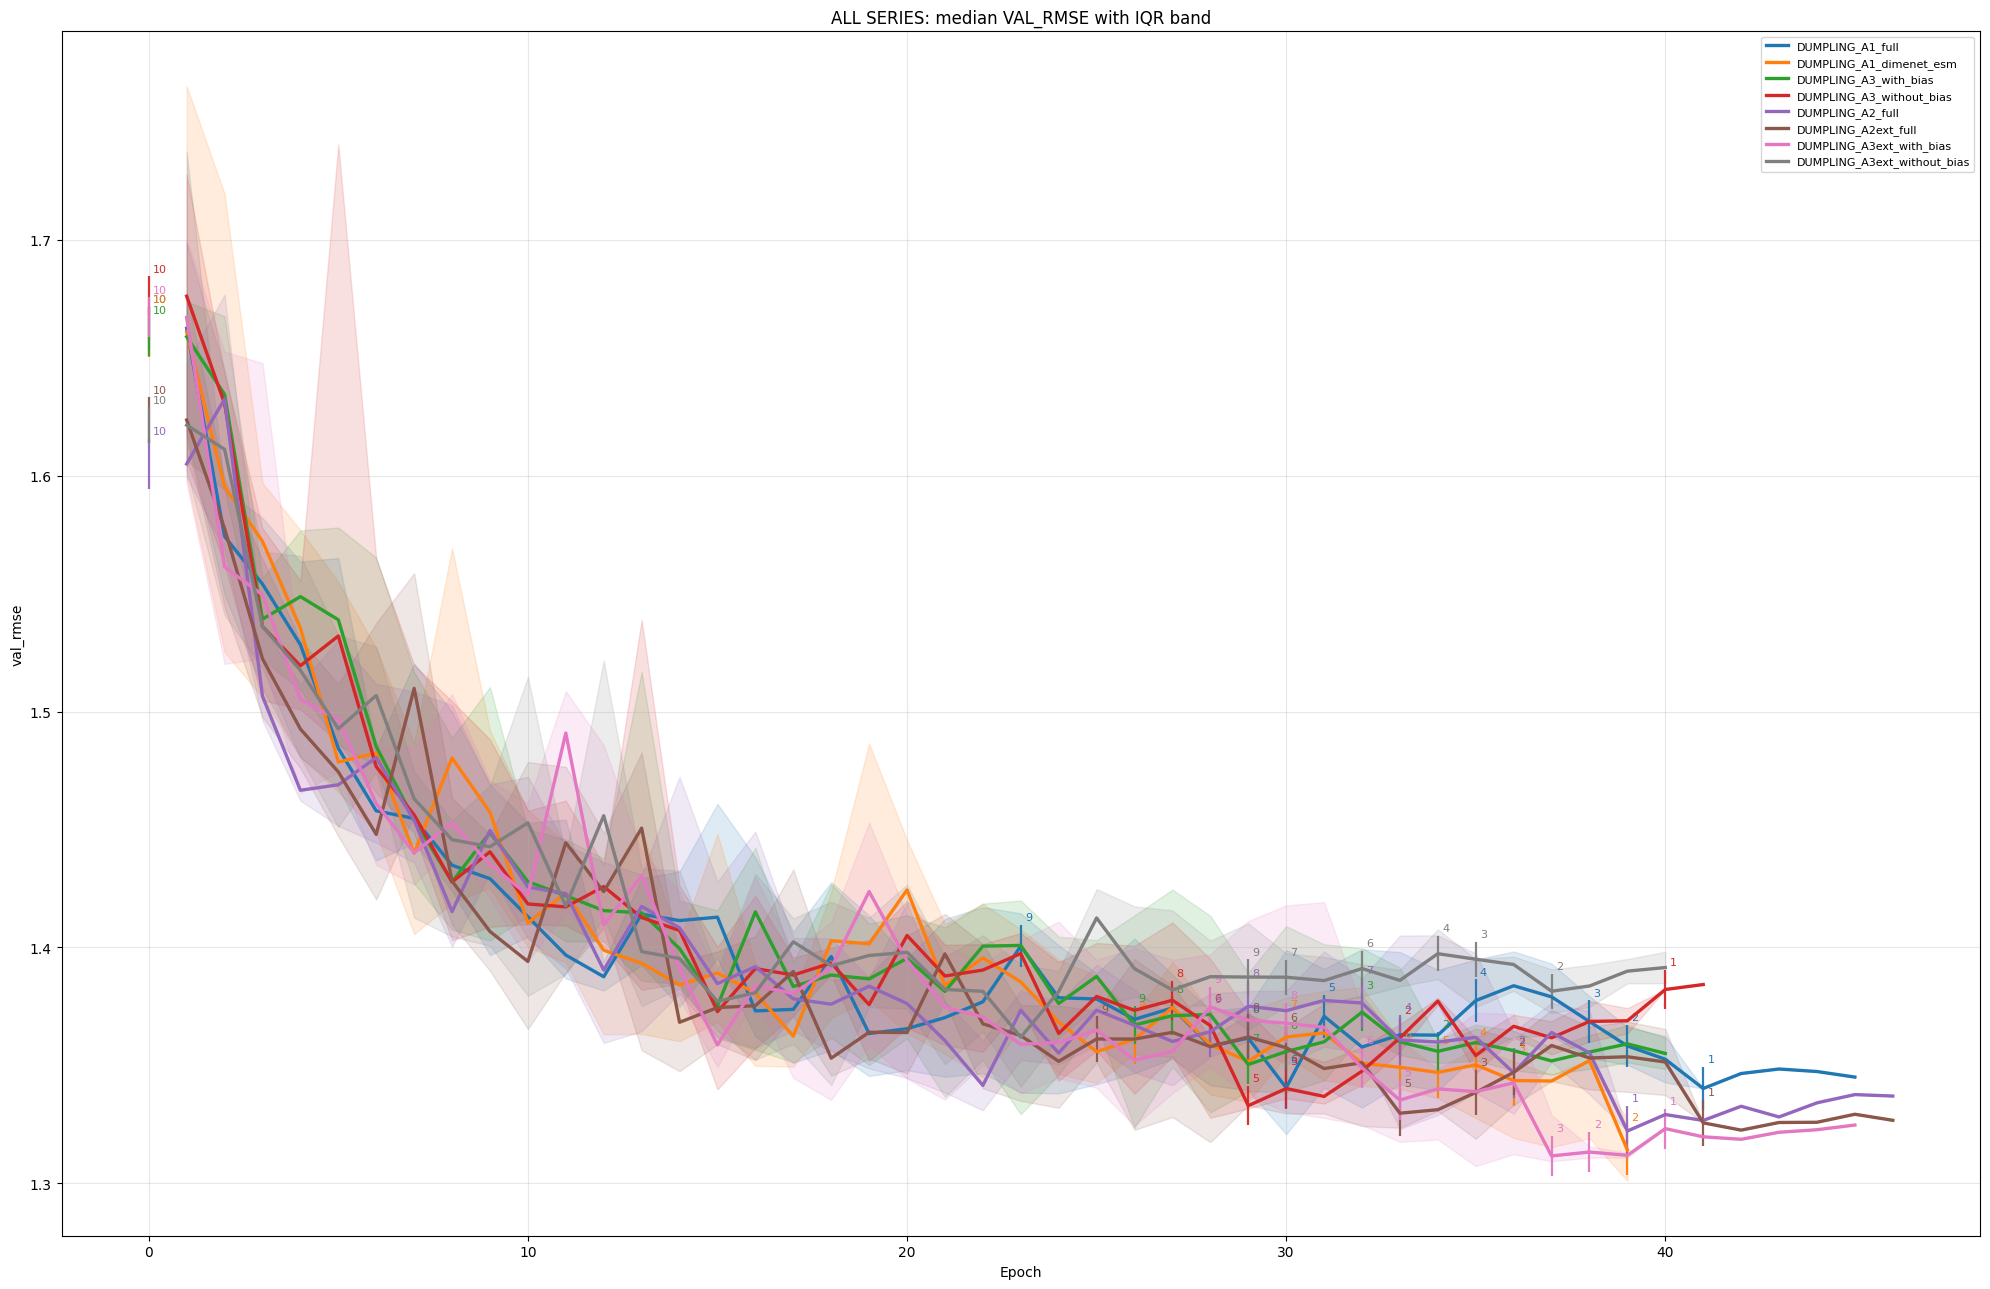

In [15]:
EXPERIMENT_NAMES=[
    # "DUMPLING_A1_esm_only",
    # "DUMPLING_A1_dimenet_only",
    "DUMPLING_A1_full",
    "DUMPLING_A1_dimenet_esm",
    "DUMPLING_A3_with_bias",
    "DUMPLING_A3_without_bias",
    "DUMPLING_A2_full",
    "DUMPLING_A2ext_full",
    "DUMPLING_A3ext_with_bias",
    "DUMPLING_A3ext_without_bias"
    ]
BAND_MODE = "iqr"
METRIC = "val_rmse"

plot_series_panel(
    df=registry_view,
    experiment_names=EXPERIMENT_NAMES,
    metric=METRIC,
    figsize=(20, 13),
    show_center=True,
    show_band=True,
    show_curves=False,
    show_count_drop_ticks=True,
    show_count_labels=True,
    band_mode=BAND_MODE,

    title=f"{"ALL SERIES"}: median {METRIC.upper()} with {BAND_MODE.upper()} band",
)

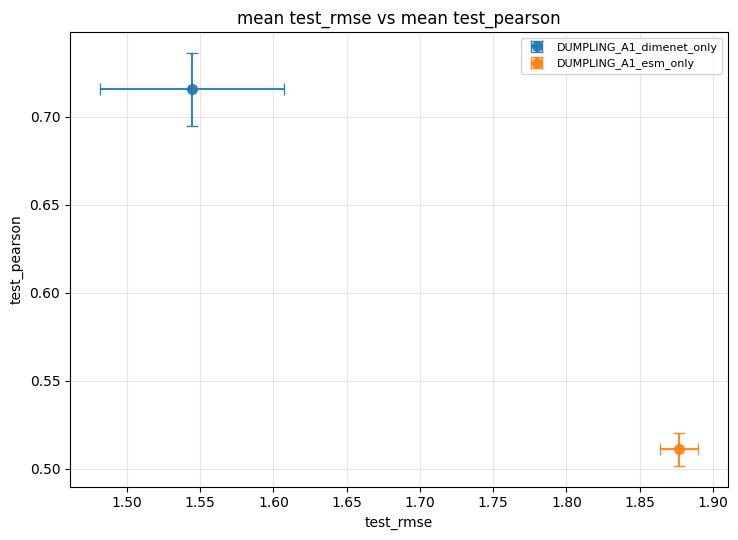

In [10]:
EXPERIMENT_NAMES=[
    "DUMPLING_A1_esm_only",
    "DUMPLING_A1_dimenet_only",
    # "DUMPLING_A1_full",
    # "DUMPLING_A1_dimenet_esm",
    # "DUMPLING_A3_with_bias",
    # "DUMPLING_A3_without_bias",
    # "DUMPLING_A2_full",
    # "DUMPLING_A2ext_full",
    # "DUMPLING_A3ext_with_bias",
    # "DUMPLING_A3ext_without_bias"
]
X_METRIC = "test_rmse"
Y_METRIC = "test_pearson"

plot_metric_summary_scatter(
    registry_view,
    x_metric=X_METRIC,
    y_metric=Y_METRIC,
    experiment_names=EXPERIMENT_NAMES,
    title=f"mean {X_METRIC} vs mean {Y_METRIC}",
    x_label=X_METRIC,
    y_label=Y_METRIC,
)
plt.show()

In [6]:
diag_df = load_series_readout_diagnostics(
    registry_view,
    "DUMPLING_A3ext_without_bias",
    runs_dir=RUNS_DIR,
)

In [7]:
diag_df_ext = load_series_readout_diagnostics(
    registry_view,
    "DUMPLING_A3ext_without_bias",
    runs_dir=RUNS_DIR,
)

In [8]:
a3_report = summarize_a3_mixture_diagnostics(diag_df)
a3_report_ext = summarize_a3_mixture_diagnostics(diag_df_ext)

In [9]:
a3_report["summary"]

,metric,n,mean,std,min,max,median
0,alpha,10,0.172723,0.343228,-0.429162,0.492572,0.338168
1,beta,10,0.057809,0.365161,-0.529505,0.633540,0.058687
2,global_branch_output_mean,10,0.177059,0.941102,-1.906745,1.311660,0.579457
3,global_contribution_mean,10,0.282148,0.147551,0.019838,0.499308,0.275069
4,global_contribution_mean_abs,10,0.730251,0.050358,0.646179,0.805112,0.730225
5,local_branch_output_mean,10,-0.343010,2.136394,-5.350764,3.502474,-0.306203
6,local_contribution_mean,10,-0.209526,0.134096,-0.448009,-0.025293,-0.228728
7,local_contribution_mean_abs,10,0.212141,0.131277,0.025293,0.448493,0.228728
8,local_to_global_abs_contribution_ratio,10,0.282640,0.168848,0.039142,0.593851,0.300743
9,local_to_global_abs_contribution_ratio_stats_mean,10,12.836054,34.401832,0.364300,116.004715,1.153922


<Axes: title={'center': 'A3 mixer parameters by run'}, xlabel='Seed', ylabel='Coefficient value'>

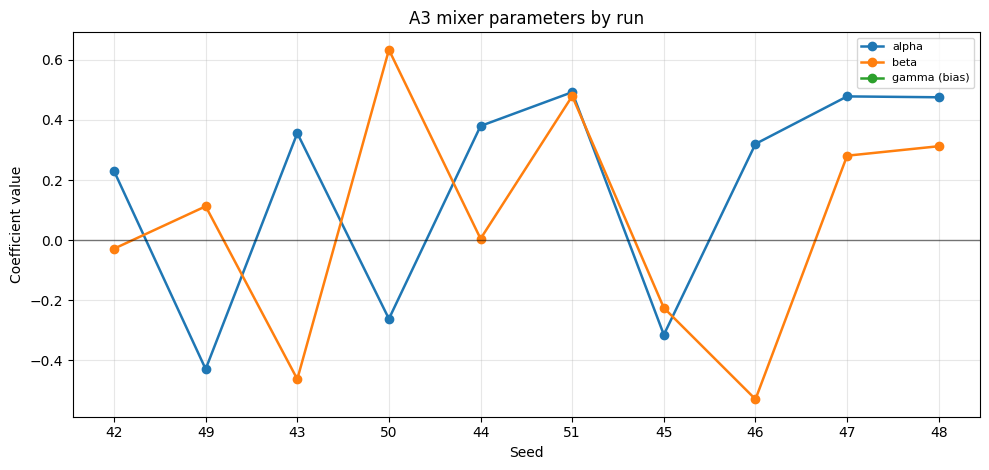

In [10]:
plot_a3_mixture_parameters(diag_df)

<Axes: title={'center': 'test_rmse vs local/global ratio (corr=0.416)'}, xlabel='local/global abs contribution ratio', ylabel='test_rmse'>

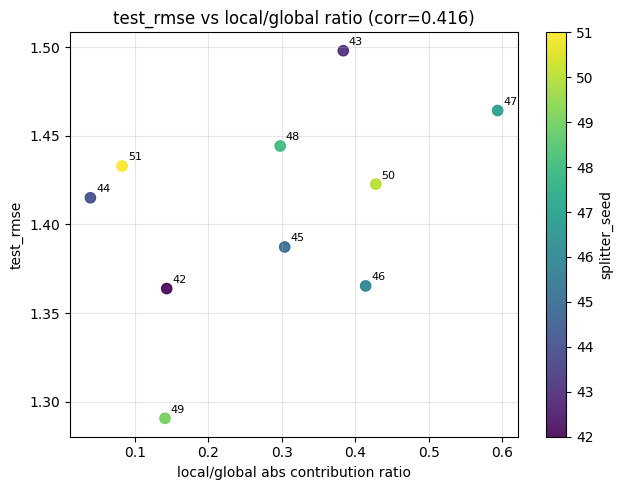

In [11]:
plot_a3_local_ratio_vs_metric(diag_df, metric="test_rmse")

<Axes: title={'center': 'test_rmse vs local/global ratio (corr=0.416)'}, xlabel='local/global abs contribution ratio', ylabel='test_rmse'>

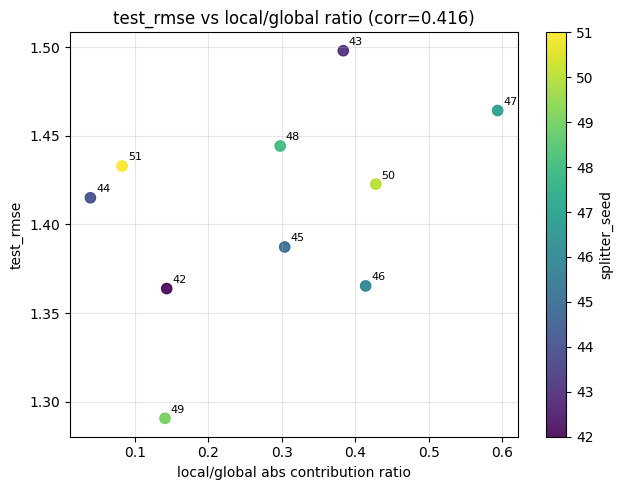

In [12]:
plot_a3_local_ratio_vs_metric(diag_df_ext, metric="test_rmse")

<Axes: title={'center': 'alpha vs beta colored by test_rmse'}, xlabel='alpha', ylabel='beta'>

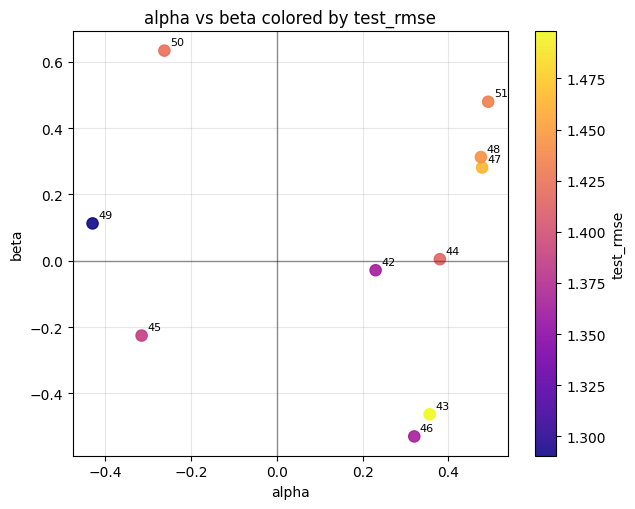

In [13]:
plot_a3_alpha_beta_scatter(diag_df)

<Axes: title={'center': 'alpha vs beta colored by test_rmse'}, xlabel='alpha', ylabel='beta'>

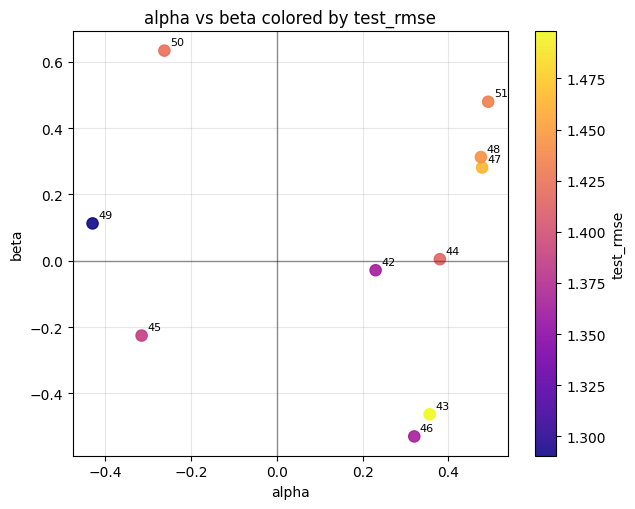

In [14]:
plot_a3_alpha_beta_scatter(diag_df_ext)

## Notes

- `plot_metric_by_seed()` was intentionally removed from the notebook flow.
- The working shapes now are:
  - curve/band plots over epochs
  - summary scatter with error bars for any metric pair
- The raw spaghetti view remains available only through the hybrid helper when needed.